## 逻辑回归
逻辑回归的思想是用一张超平面（二维时将退化为直线）将所有的样本点划分开，一边为真（1），一边为假（0），各样本点和超平面的距离则反映了其判断为该类别的概率。

逻辑回归的实现方面，实际上是在线性回归的基础上套了一层 sigmoid 函数：
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$
其中
$$z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b$$
训练过程中会不断调整 $w_1,w_2,\dots,w_n,b$ 的取值至当前条件的最佳值。

预测时返回的是 [0, 1] 区间内的概率值，再将0.5以上概率的划为真（1），其他的化为假（0）。

问题：基于待测者的各项指标来训练可以判断其是否患有乳腺癌的模型
这是一个典型的二分类问题，基于一组特征数据来对判断对象进行分类

In [83]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

### **1.导入数据集并观察其结构**

#### 1.1 可直接用当前目录下的 breast_cancer.csv 文件

In [84]:
df = pd.read_csv('breast_cancer.csv')
print(df)

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean concavity  mean concave points  mea

#### 1.2 也可以使用 scikit-learn 中内置的 load_breast_cancer 来导入数据

In [85]:
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer()
print(bc['DESCR'])
bc_df = pd.DataFrame(bc.data, columns=bc.feature_names)
print(bc_df)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

### **2.划分训练集和测试集**

#### 2.1 对于使用 pandas 导入的数据的划分方式

In [86]:
X = df.iloc[:, :-1].values  #保留处最后一列 target 列意外的特征列
y = df.iloc[:, -1].values   #切除最后一列，即 target 列
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#### 2.2 对于直接从 scikit-learn 库中导入的数据的划分方式

In [87]:
X = bc.data
y = bc.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### **3.数据标准化**
由于逻辑回归对于数据的尺度也较为敏感，故仍然需要对数据进行标准化处理
> 这里值得注意的是，关于标准化的规则只能由训练集得出，如果此阶段使用的是整个数据集，这就算是测试数据泄露了，**当然，这并不是说测试数据不用标准化**。

#### 3.1 手动标准化

In [88]:
mean = X_train.mean(axis = 0)
std = X_train.std(axis = 0)
X_train_std = (X_train - mean) / std
X_test_std = (X_test - mean) /std

#### 3.2 使用 scikit-learn 库中的 StandardScaler 进行标准化处理

In [89]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### **4.模型训练与预测**

In [90]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#获取一个二位列表，第一列为各样本判断为0的概率，第二列为各样本判断为1的概率
y_prob = model.predict_proba(X_test)
print(y_test)
print(y_pred)

#创建一个包含各样本判断结果及判断为1的概率值的 DataFrame
prob = pd.DataFrame(y_pred, columns = ['Predicted'])
prob['Probability'] = y_prob[:, 1]
prob

[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 0 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0]
[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 0 0]


D:\Anaconda\envs\MM\Lib\site-packages\sklearn\linear_model\_logistic.py:456: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


,Predicted,Probability
0,1,8.864098e-01
1,0,9.009362e-06
2,0,3.079095e-03
3,1,9.994899e-01
4,1,9.999394e-01
...,...,...
109,1,9.678046e-01
110,0,6.768252e-04
111,1,9.986917e-01
112,0,4.573002e-01


### **5.评估预测结果**

#### 5.1 准确率
这是最直观，但也是最粗糙的评价方案
> 假想100个嫌疑人里只有一个凶手，模型把他们全预测为好人，正确率达到99%，但并没有达到我们想要的找出凶手的效果

In [91]:
correct = np.sum(y_pred == y_test)
total = len(y_test)
acc = correct / total
print(f"测试集准确率为：{acc:.2%}")

测试集准确率为：97.37%


#### 5.2 混淆矩阵
把预测结果分为四类（以二分类为例，正例为1，负例为0）
|   | 预测为0（负） | 预测为1（正）|
|---|---------|-----|
| 真实为0 | TN | FP |
| 真实为1 | FN | TP |

In [92]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred)
print(cm)
TN, FP = cm[0, 0], cm[0, 1]
FN, TP = cm[1, 0], cm[1, 1]

[[41  2]
 [ 1 70]]


这里我们可以使用 sklearn.metrics 中的 classification_report 的到关于预测结果的综合报告

此处会输出`precision`（精确率）, `recall`（召回率）, `f1-score`
| 指标 | 计算公式 | 含义 |
|-----|-----|------|
| `precision`| `TP / (TP + FP)`| 在所有被模型预测为 1（正例） 的样本中，有多少是真正的 1 |
| `recall`| `TP / (TP + FN)`| 在所有真实为 1（正例） 的样本中，模型成功找出了多少。 |
| `f1-score`| `2 * (precision * recall) / (precision + recall)`|精确率和召回率的“调和平均数”,当精确率和召回率互相矛盾（一个高一个低）时，用 `f1-score` 来综合评判模型的“稳健性”。 |

In [93]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



### 6.预测结果可视化
用 ROC 曲线和混淆矩阵热力图这两张常用的指标图来直观评估模型效果

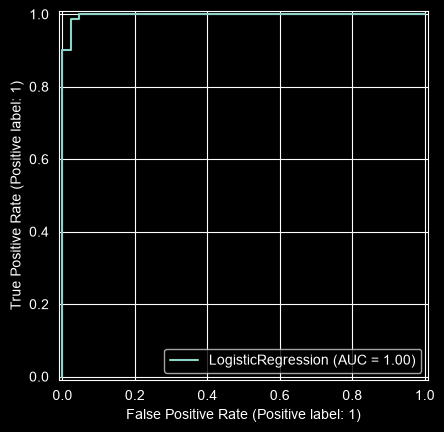

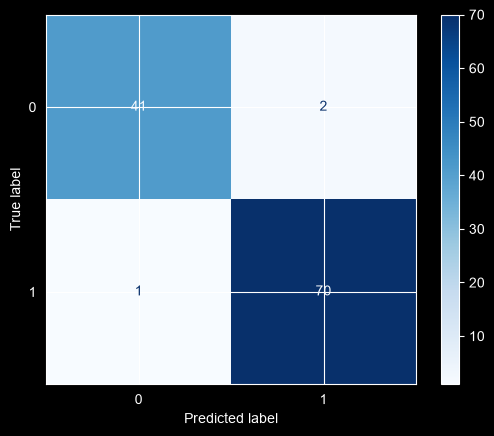

In [94]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

# ROC 曲线
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show('lr_roc_curve.png')

# 混淆矩阵热力图
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.show('lr_confusion_matrix.png')

---
最后，关于 LogisticRegression ，实际上有很多参数是可以由我们根据实际情况进行调整的，这里我们各几个常见的参数。
| 参数 | 默认值 | 常用设置 | 一句话解释 |
| :--- | :--- | :--- | :--- |
| `penalty` | `'l2'` | `'l2'`、`'l1'`、`'none'` | 正则化类型，防止过拟合 |
| `C` | `1.0` | `0.01` ~ `100`（对数搜索） | 正则化强度的倒数，越小正则越强 |
| `solver` | `'lbfgs'` | `'lbfgs'`、`'liblinear'`、`'saga'` | 优化算法，`l1` 需用 `'liblinear'` 或 `'saga'` |
| `max_iter` | `100` | 出现收敛警告时改为 `1000`+ | 最大迭代次数，不够就加大 |
| `class_weight` | `None` | `'balanced'` 或 `{0:1, 1:10}` | 处理类别不平衡 |
| `multi_class` | `'auto'` | `'multinomial'`（多分类 softmax） | 多分类策略 |
| `random_state` | `None` | `42` 或任意整数 | 固定随机种子，保证结果可复现 |


当然，作为分类算法的基础角色，逻辑回归并不是什么时候都适用的，至少在下面的几种情况下，我们通常有更好的选择
1. **数据严重线性不可分**
    - 几何直观上就是特征空间中的数据不再能被一条线（或一个超平面）分开了，一定程度上也可以通过特征工程来
    - 这种情况下，虽然一定程度内可以通过特征工程来得到不错的结果，但通常优先考虑：带核函数的SVM、决策树/随机森林、神经网络等。
2. **特征之间高度共线性**
    - 也就是某一个或几个特征的数据可以由其他特征在较大程度上线性表示，也就是特征之间呈现出较大的“线性相关”性
    - 这种情况下可能仍然能得到精确度都较高的模型，但模型的权重可解释性会变弱，线性相关的几个特征会共享一组权重，而对其的分配比例会在训练过程中呈现较大程度的震荡，难以收敛到一个稳定的值
    - 可以先做特征选择、用正则化（L1/L2）、或用PCA降维
3. **异常值较多的数据**
    - 逻辑回归使用对数似然损失，对异常值没有像线性回归的平方损失那么敏感，但如果某些样本特征极端、标签又错误，决策边界会被明显拉偏
    - 可以试试用`RobustScaler`来代替`StandardScaler`做预处理，或者换用对异常值更鲁棒的模型（如随机森林）。
4. **类别极度不平衡且概率校准要求高**
    - 这种情况下，如果不做任何处理，最终获得的模型可能会偏向多数类。如果使用的场景更关注少数类（如欺诈检测、罕见病诊断），且需要准确概率，可能需要配合：
5. **特征太多（尤其是稀疏高维特征）且样本少**
    - 逻辑回归配合 L1（岭回归） 正则化可以做特征选择。但如果特征极多（如文本的 n-gram 矩阵）且样本很少，容易过拟合
    - 此时我们可以选择**朴素贝叶斯**或**带正则化的线性 SVM**。